# Customer Churn Records - Descriptive Analysis

## Import Required Libraries
Import necessary libraries for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load and Explore Data
Load the customer churn dataset and examine its structure.

In [3]:
# Load the dataset
df = pd.read_csv('Customer-Churn-Records.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First Few Rows:")
print(df.head())
print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

Dataset Shape: (10000, 18)

First Few Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1        

## Missing Values Analysis

In [4]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")
print("\nMissing Values Percentage:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0] if missing_percent.sum() > 0 else "No missing values!")

Missing Values:
No missing values found!

Missing Values Percentage:
No missing values!


## Descriptive Statistics - Numerical Features

In [13]:
# Summary statistics for numerical columns
print("Summary Statistics:")
print(df.describe().round(2))
print("\n" + "="*50)

# Additional statistics
print("Additional Statistics:")
print(f"Skewness:\n{df.skew(numeric_only=True).round(3)}\n")
print(f"Kurtosis:\n{df.kurtosis(numeric_only=True).round(3)}")

Summary Statistics:
       RowNumber   CustomerId  CreditScore       Age    Tenure    Balance  \
count   10000.00     10000.00     10000.00  10000.00  10000.00   10000.00   
mean     5000.50  15690940.57       650.53     38.92      5.01   76485.89   
std      2886.90     71936.19        96.65     10.49      2.89   62397.41   
min         1.00  15565701.00       350.00     18.00      0.00       0.00   
25%      2500.75  15628528.25       584.00     32.00      3.00       0.00   
50%      5000.50  15690738.00       652.00     37.00      5.00   97198.54   
75%      7500.25  15753233.75       718.00     44.00      7.00  127644.24   
max     10000.00  15815690.00       850.00     92.00     10.00  250898.09   

       NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary   Exited  \
count       10000.00   10000.00        10000.00         10000.00  10000.0   
mean            1.53       0.71            0.52        100090.24      0.2   
std             0.58       0.46            0.50        

## Categorical Features Analysis

In [6]:
# Analyze categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{col} - Value Counts:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")


Surname - Value Counts:
Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Salinas       1
Cleveland     1
Kashiwagi     1
Aldridge      1
Burbidge      1
Name: count, Length: 2932, dtype: int64
Unique values: 2932

Geography - Value Counts:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Unique values: 3

Gender - Value Counts:
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Unique values: 2

Card Type - Value Counts:
Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64
Unique values: 4


C:\Users\Luan\AppData\Local\Temp\ipykernel_69756\3096864258.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## Correlation Analysis

Correlation with Churn (Exited):
Exited                1.000
Complain              0.996
Age                   0.285
Balance               0.119
EstimatedSalary       0.012
Point Earned         -0.005
Satisfaction Score   -0.006
CustomerId           -0.006
HasCrCard            -0.007
Tenure               -0.014
RowNumber            -0.016
CreditScore          -0.027
NumOfProducts        -0.048
IsActiveMember       -0.156
Name: Exited, dtype: float64


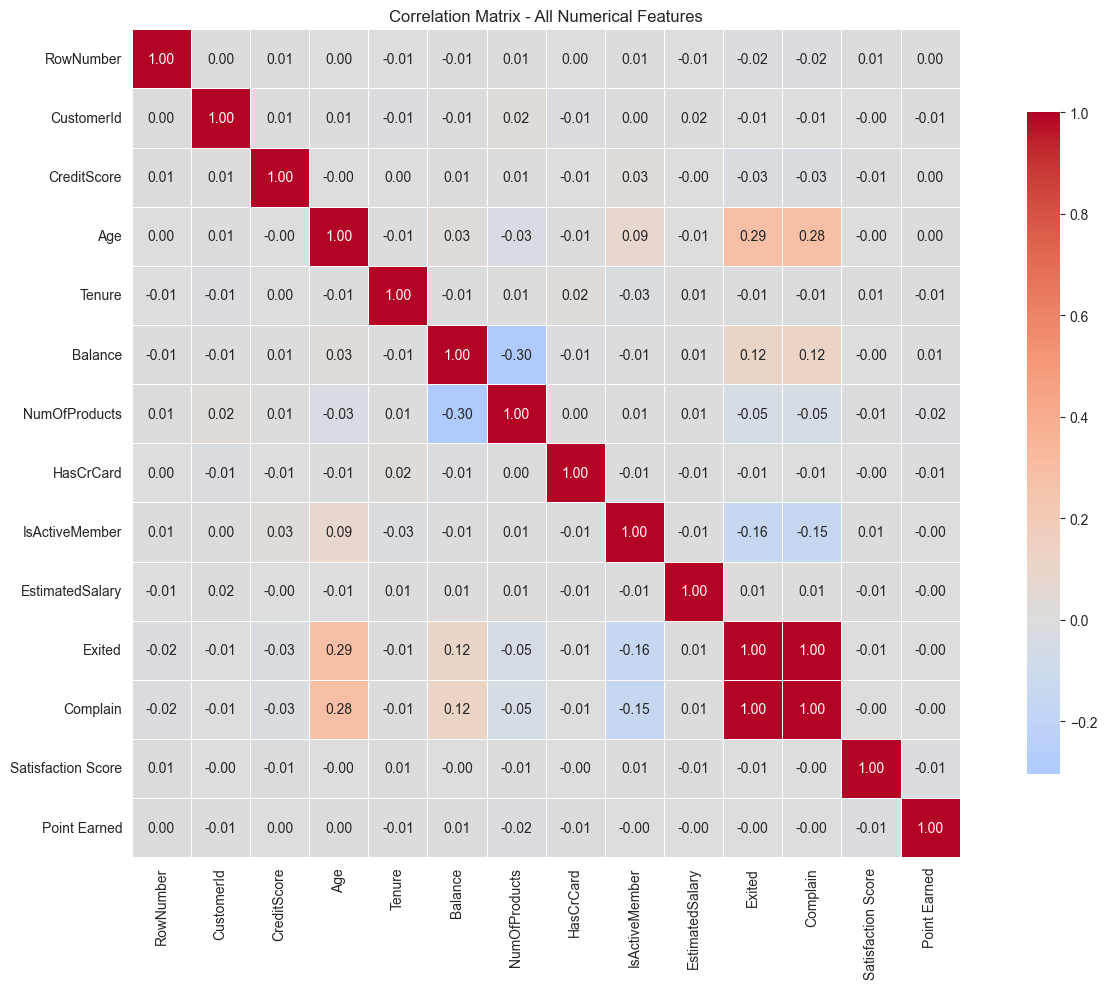

In [7]:
# Calculate correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Display correlation with target variable (Exited)
print("Correlation with Churn (Exited):")
print(correlation_matrix['Exited'].sort_values(ascending=False).round(3))

# Visualize correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numerical Features')
plt.tight_layout()
plt.show()

## Distribution Analysis - Numerical Features

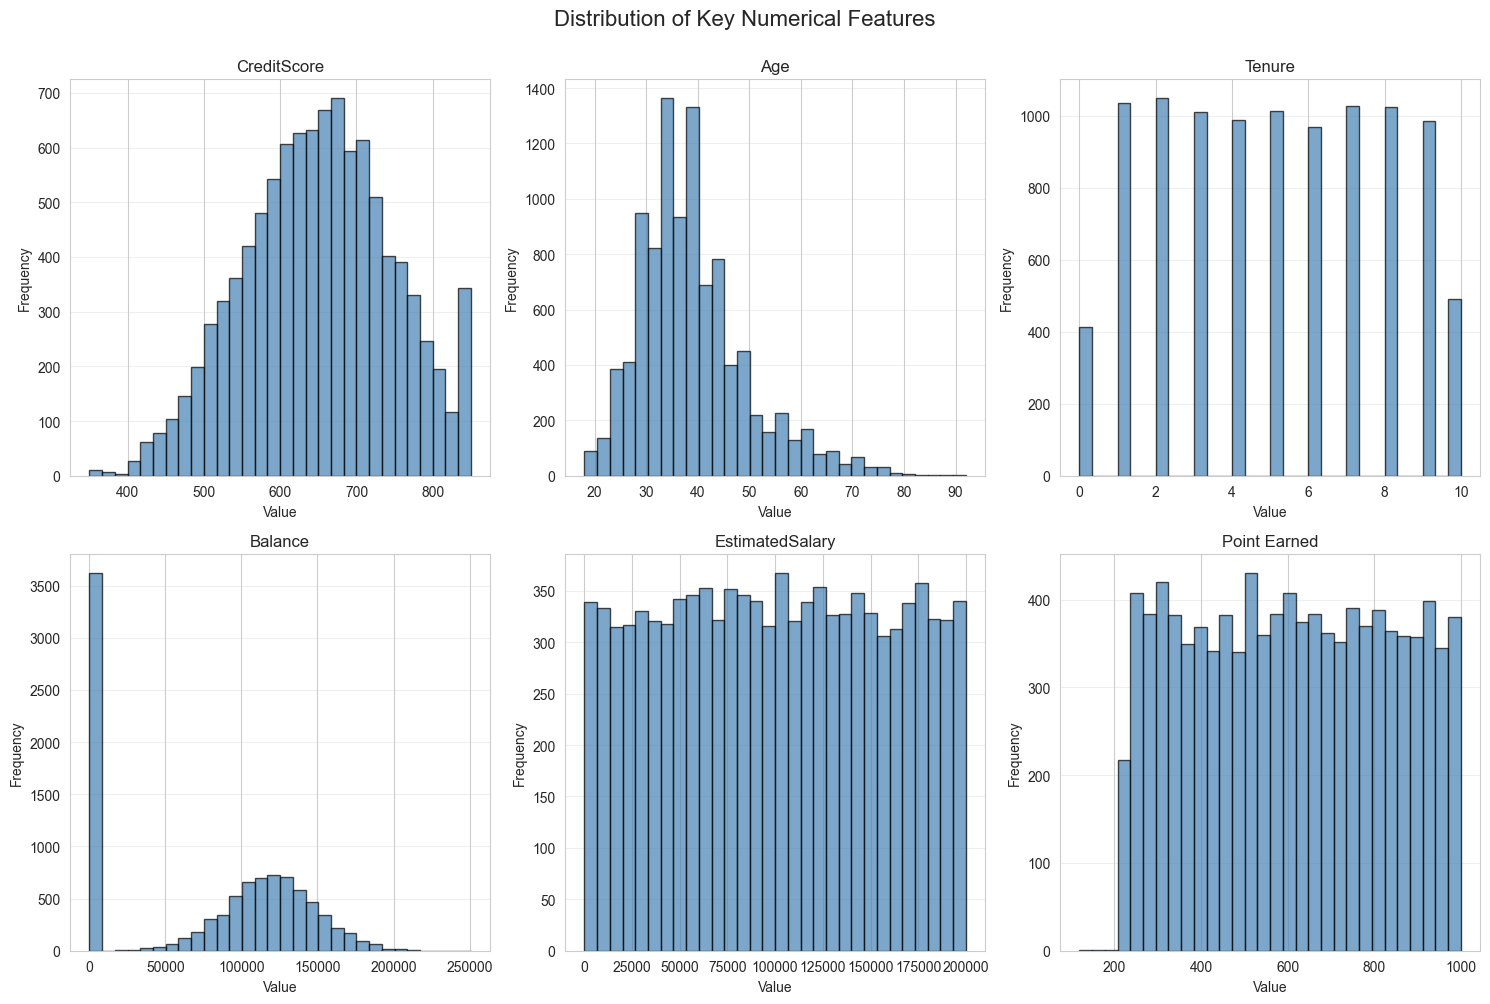

In [8]:
# Plot distributions of key numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16, y=1.00)

features_to_plot = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point Earned']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'{feature}')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Churn Analysis

Churn Distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64

Churn Rate: 20.38%


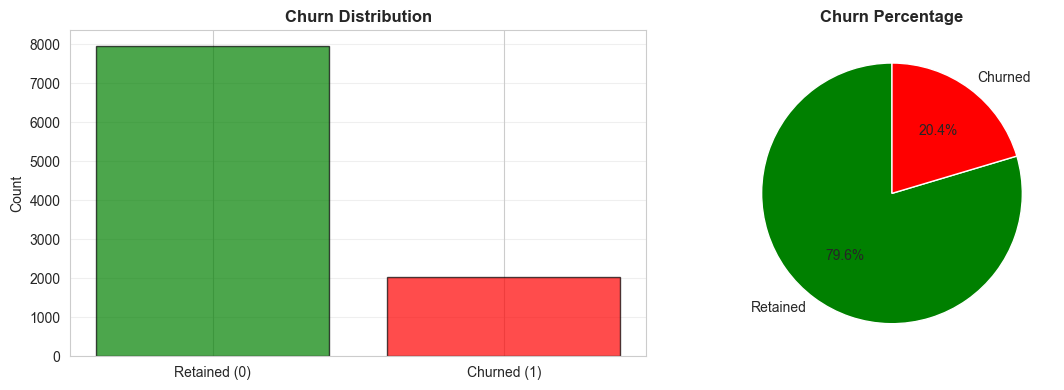

In [9]:
# Analyze churn distribution
print("Churn Distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {(df['Exited'].sum() / len(df) * 100):.2f}%")

# Visualize churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
churn_counts = df['Exited'].value_counts()
colors = ['green', 'red']
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Churn Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Churn Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Churn by Categorical Features

Churn Rate by Geography:
           count  sum   mean
Geography                   
France      5014  811  0.162
Germany     2509  814  0.324
Spain       2477  413  0.167

Churn Rate by Gender:
        count   sum   mean
Gender                    
Female   4543  1139  0.251
Male     5457   899  0.165

Churn Rate by Active Member Status:
                count   sum   mean
IsActiveMember                    
0                4849  1303  0.269
1                5151   735  0.143


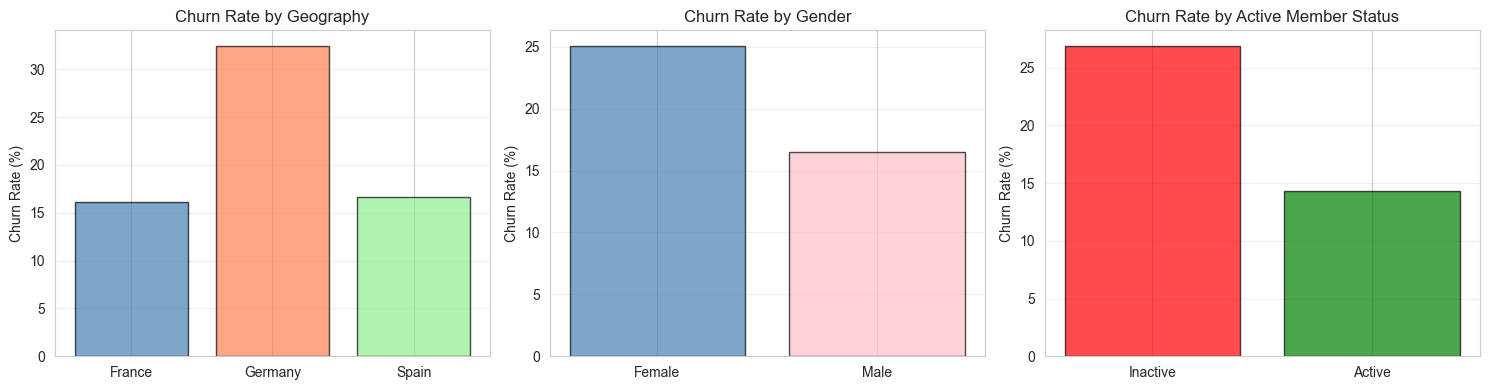

In [10]:
# Analyze churn by categorical features
print("Churn Rate by Geography:")
print(df.groupby('Geography')['Exited'].agg(['count', 'sum', 'mean']).round(3))

print("\n" + "="*50)
print("Churn Rate by Gender:")
print(df.groupby('Gender')['Exited'].agg(['count', 'sum', 'mean']).round(3))

print("\n" + "="*50)
print("Churn Rate by Active Member Status:")
print(df.groupby('IsActiveMember')['Exited'].agg(['count', 'sum', 'mean']).round(3))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
axes[0].bar(geo_churn.index, geo_churn.values, color=['steelblue', 'coral', 'lightgreen'], 
            alpha=0.7, edgecolor='black')
axes[0].set_title('Churn Rate by Geography')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].grid(axis='y', alpha=0.3)

# Churn by Gender
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[1].bar(gender_churn.index, gender_churn.values, color=['steelblue', 'pink'], 
            alpha=0.7, edgecolor='black')
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].grid(axis='y', alpha=0.3)

# Churn by Active Member Status
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
axes[2].bar(['Inactive', 'Active'], active_churn.values, color=['red', 'green'], 
            alpha=0.7, edgecolor='black')
axes[2].set_title('Churn Rate by Active Member Status')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Key Insights

In [11]:
print("="*60)
print("DESCRIPTIVE ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset Overview:")
print(f"  - Total Records: {len(df):,}")
print(f"  - Total Features: {len(df.columns)}")
print(f"  - Numerical Features: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  - Categorical Features: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\nChurn Metrics:")
print(f"  - Churned Customers: {df['Exited'].sum():,}")
print(f"  - Retained Customers: {(df['Exited'] == 0).sum():,}")
print(f"  - Churn Rate: {(df['Exited'].mean() * 100):.2f}%")

print(f"\nKey Statistics:")
print(f"  - Average Age: {df['Age'].mean():.2f} years")
print(f"  - Average Credit Score: {df['CreditScore'].mean():.2f}")
print(f"  - Average Tenure: {df['Tenure'].mean():.2f} years")
print(f"  - Average Estimated Salary: ${df['EstimatedSalary'].mean():,.2f}")
print(f"  - Average Account Balance: ${df['Balance'].mean():,.2f}")

print(f"\nGeography Distribution:")
for geo in df['Geography'].unique():
    count = len(df[df['Geography'] == geo])
    print(f"  - {geo}: {count:,} ({count/len(df)*100:.1f}%)")

print("\n" + "="*60)

DESCRIPTIVE ANALYSIS SUMMARY

Dataset Overview:
  - Total Records: 10,000
  - Total Features: 18
  - Numerical Features: 14
  - Categorical Features: 4

Churn Metrics:
  - Churned Customers: 2,038
  - Retained Customers: 7,962
  - Churn Rate: 20.38%

Key Statistics:
  - Average Age: 38.92 years
  - Average Credit Score: 650.53
  - Average Tenure: 5.01 years
  - Average Estimated Salary: $100,090.24
  - Average Account Balance: $76,485.89

Geography Distribution:
  - France: 5,014 (50.1%)
  - Spain: 2,477 (24.8%)
  - Germany: 2,509 (25.1%)



C:\Users\Luan\AppData\Local\Temp\ipykernel_69756\4098810078.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"  - Categorical Features: {len(df.select_dtypes(include=['object']).columns)}")
